# 02 - Preprocesamiento

Objetivo: visualizar varias imagenes pasando por el flujo actual: escala de grises, recorte de boca, filtro Gaussiano ligero, redimensionamiento, normalizacion y vectorizacion.

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import DATASET_DIR, IMAGE_SIZE
from src.preprocessing import crop_mouth_region, preprocess_image

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

## Seleccion de muestras

Se toman ejemplos de ambas clases para comprobar que el recorte de boca sea consistente.

In [2]:
def list_images(split, class_name, limit=4):
    folder = DATASET_DIR / split / class_name
    images = [p for p in sorted(folder.rglob('*')) if p.suffix.lower() in VALID_EXTENSIONS]
    return images[:limit]

sample_images = (
    [(path, 'no_yawn') for path in list_images('train', 'no_yawn', 4)] +
    [(path, 'yawn') for path in list_images('train', 'yawn', 4)]
)

for path, class_name in sample_images:
    print(class_name, '->', path.name)

no_yawn -> 00.jpg
no_yawn -> 00001-2876027730.png
no_yawn -> 00009-2876027738.png
no_yawn -> 00010-2876027739.png
yawn -> 00000-1529441125.png
yawn -> 00001-2515102071.png
yawn -> 00001-3037815734.png
yawn -> 00002-227722405.png


## Vista del flujo completo

Cada fila muestra una imagen diferente y cada columna una etapa del preprocesamiento.

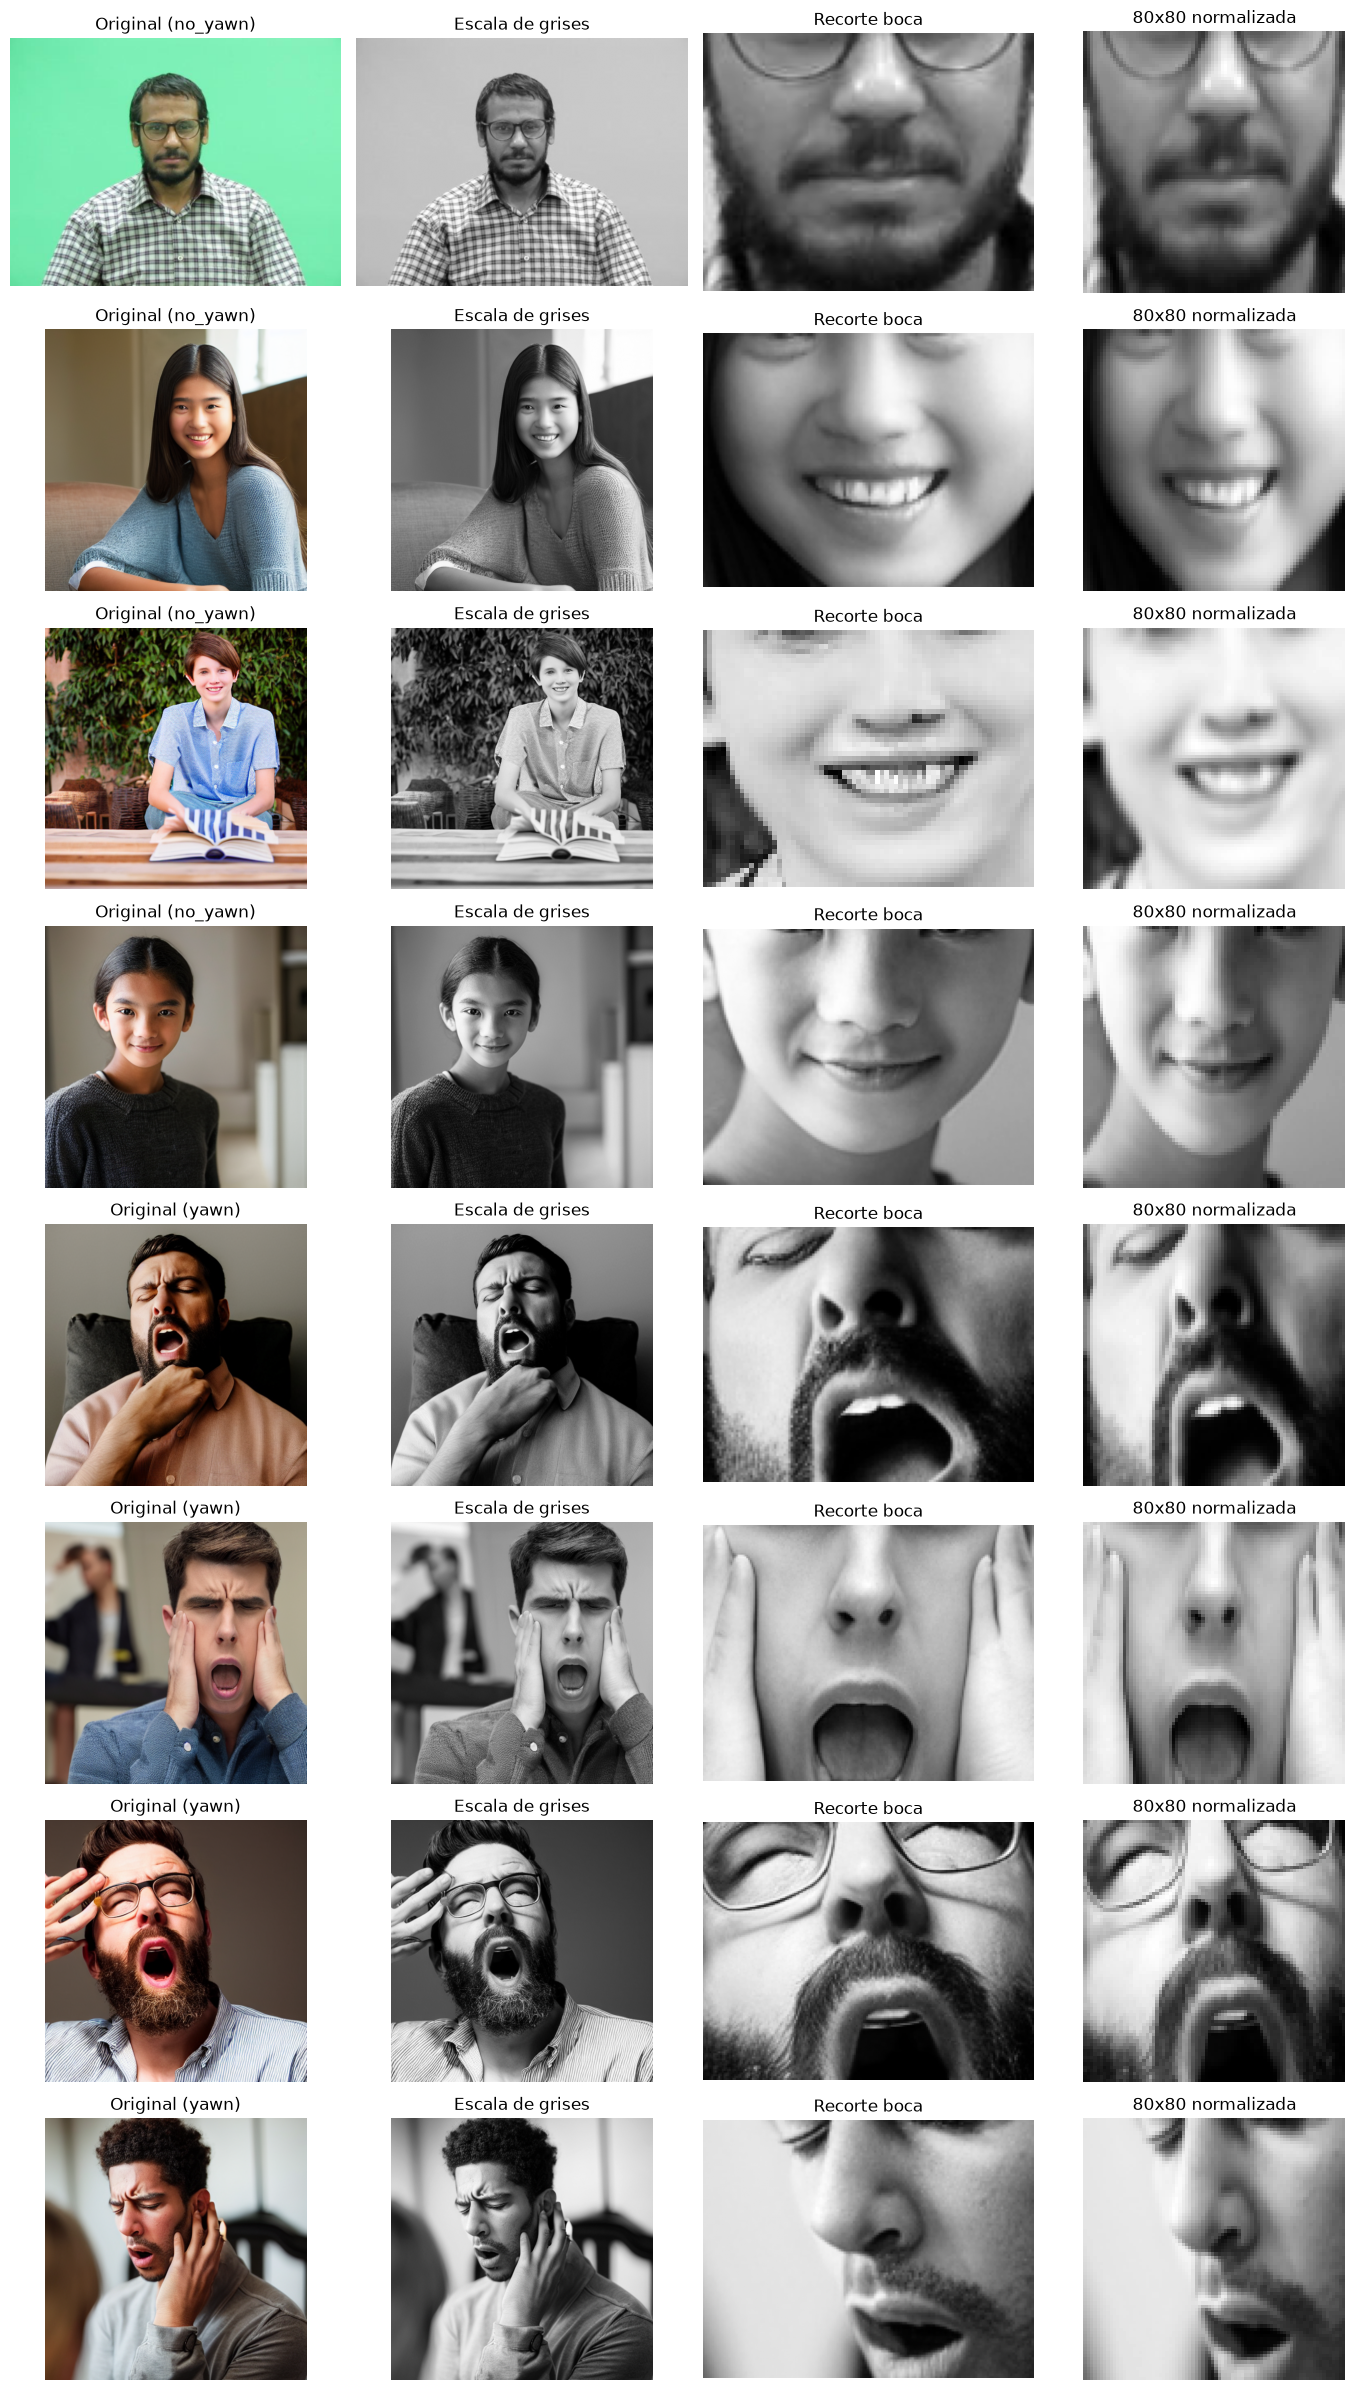

In [3]:
def process_steps(image_path):
    original = cv2.imread(str(image_path))
    if original is None:
        raise ValueError(f'No se pudo leer: {image_path}')

    rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    mouth = crop_mouth_region(gray)
    blurred = cv2.GaussianBlur(mouth, (3, 3), 0)
    resized = cv2.resize(blurred, IMAGE_SIZE)
    normalized = resized.astype('float32') / 255.0
    vector = normalized.flatten()
    return rgb, gray, mouth, normalized, vector

if sample_images:
    fig, axes = plt.subplots(len(sample_images), 4, figsize=(14, 3 * len(sample_images)))
    if len(sample_images) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (image_path, class_name) in enumerate(sample_images):
        rgb, gray, mouth, normalized, vector = process_steps(image_path)
        images = [rgb, gray, mouth, normalized]
        titles = [
            f'Original ({class_name})',
            'Escala de grises',
            'Recorte boca',
            '80x80 normalizada',
        ]

        for col, (image, title) in enumerate(zip(images, titles)):
            cmap = None if col == 0 else 'gray'
            axes[row, col].imshow(image, cmap=cmap)
            axes[row, col].set_title(title)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Aun no hay imagenes en datasets/.')

## Vector final

La entrada del MLP ahora tiene `6400` caracteristicas porque cada recorte se redimensiona a `80x80`.

In [ ]:
if sample_images:
    vector = preprocess_image(sample_images[0][0])
    print('Vector:', vector.shape)
    print('Min:', vector.min())
    print('Max:', vector.max())